In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [44]:
data = pd.read_csv('./data/lab_3_data.csv') 
months = data.iloc(0)
data

,Год,янв,фев,мар,апр,май,июн,июл,авг,сен,окт,ноя,дек,средняя
0,1817,999.9,999.9,999.9,999.9,999.9,999.9,999.9,15.5,4.6,-3.1,-10.5,-25.2,999.9
1,1818,-13.0,-20.2,-4.5,0.6,5.7,13.9,14.2,14.3,9.0,-2.0,-12.2,-9.7,-0.3
2,1819,-11.0,-17.3,-6.9,-2.9,3.7,15.6,15.8,12.8,9.6,2.1,-12.5,-17.2,-0.7
3,1820,-20.2,-17.2,-2.6,2.9,8.5,15.0,17.3,12.6,8.5,2.7,-7.6,-15.1,0.4
4,1821,-12.8,-12.6,-7.3,0.1,9.3,13.2,17.1,13.5,6.3,4.0,-4.5,-11.6,1.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,2015,-15.3,-6.6,-1.8,2.9,13.6,16.2,13.9,12.4,10.5,-0.2,-5.3,-6.6,2.8
199,2016,-16.6,-3.6,-4.7,4.8,11.4,14.6,19.9,18.1,9.0,1.8,-10.9,-15.8,2.3
200,2017,-14.2,-10.3,-1.2,1.0,5.0,12.4,18.3,16.0,7.5,2.3,-1.8,-5.5,2.5
201,2018,-9.6,-12.2,-10.8,1.6,8.1,13.5,19.5,14.5,9.6,2.9,-4.9,-9.8,1.9


In [108]:
month = 'янв'
first_row = 2

H = 0.1

count_rows = 12

X = []
for i in range(count_rows):
    X.append(H * i)
Y = data.iloc[first_row:first_row + count_rows]

X = list(X)
Y = list(Y[month])
X, Y

([0.0,
  0.1,
  0.2,
  0.30000000000000004,
  0.4,
  0.5,
  0.6000000000000001,
  0.7000000000000001,
  0.8,
  0.9,
  1.0,
  1.1],
 [-11.0,
  -20.2,
  -12.8,
  -8.9,
  -18.8,
  -18.4,
  -9.5,
  -14.9,
  -11.0,
  -26.9,
  -15.6,
  -15.1])

In [109]:
n_x = []
n_y = []
for i in range(0, len(Y)):
    if Y[i] != 999.9:
        n_x.append(X[i])
        n_y.append(Y[i])
        
X = n_x.copy()
Y = n_y.copy()

        

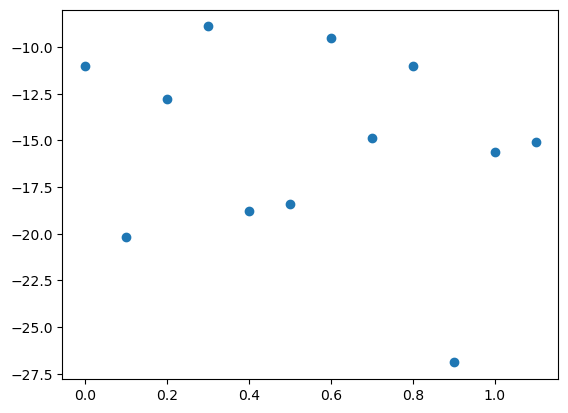

In [110]:
plt.scatter(X, Y)

In [111]:
def L_i(x, ind, table_x):
    res = 1
    for j in range(0, len(table_x)):
        if j != ind:
            res *= (x - table_x[j]) / (table_x[ind] - table_x[j])
    return res

In [112]:
def InterpolLag(x):
    global X, Y
    
    result = 0
    for i in range(0, len(X)):
        result += Y[i] * L_i(x, i, X)
    return result

In [160]:
X_n = X[:5]
Y_n = Y[:5]


x = np.linspace(X_n[0], X_n[5], 100)
y = [InterpolLag(el) for el in x]


print("Интерполяция полиномом Лагранжа\nДанные:")
print(X_n, Y_n, sep='\n')
plt.plot(x, y)
plt.scatter(X_n, Y_n)

IndexError: list index out of range

In [115]:
def k_coeff(ind, k):
    res = 1
    for j in range(ind):
        res *= k - j
        
    return res

In [116]:
def fact(a):
    res = 1
    for i in range(1, a):
        res *= i
        
    return res

In [142]:
def FiniteDifferenceFO(i, table_y):
    return table_y[i + 1] - y[i]

def FiniteDifference(i, k):
    global Y
    res = Y[k]
    
    
    for j in range(1, 1 + len(Y)):
        if j % 2 == 1:
            sgn_coeff = -1
        else:
            sgn_coeff = 1
            
        res += sgn_coeff * k_coeff(j, k) * Y[0 + k - j] / fact(j)
    return res

In [154]:
def x_coeff(ind):
    global X
    res = 1
    for i in range(ind):
        res *= X[ind] - X[i]
    return res

In [155]:
def InterpolNewtonFK(x):
    global X, Y
    result = Y[0]
    
    for i in range(1, len(X)):
        result += FiniteDifference(0, i) * x_coeff(i) / fact(i) / np.pow(H, i)
    return result
        

Интерполяция полиномом Лагранжа
Данные:
[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5]
[-11.0, -20.2, -12.8, -8.9, -18.8, -18.4]


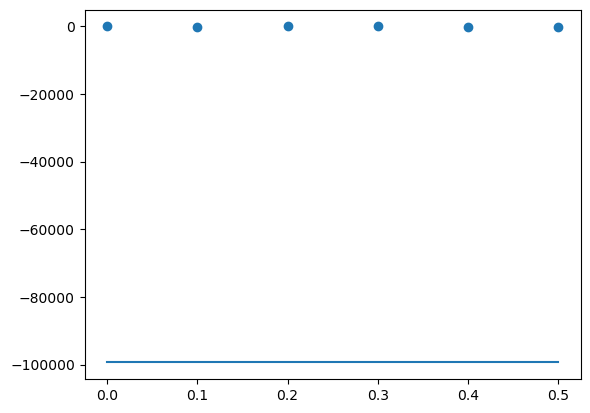

In [166]:
X_n = X[:6]
Y_n = Y[:6]

x_n = np.linspace(X[0], X[5], 100)
y_n = [InterpolNewtonFK(el) for el in x_n]


print("Интерполяция полиномом Лагранжа\nДанные:")
print(X_n, Y_n, sep='\n')
plt.plot(x_n, y_n)
plt.scatter(X_n, Y_n)